## 可视化

In [1]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
from PIL import Image
import matplotlib
import sys
sys.path.append("..")
from util.metric import convert_nl2abs_depth, dataset2params


def merge_channel(vox):
    vox = vox - vox.min()
    new_voxel = vox[0]
    for i in range(1, vox.shape[0]):
        new_voxel = new_voxel + vox[i]
    return new_voxel


def vis_1_channel(arr, cmap_name="Spectral"):
    cmap = matplotlib.colormaps.get_cmap(cmap_name)
    arr = (arr - arr.min()) / (arr.max() - arr.min()) * 255.0
    arr = arr.astype(np.uint8)

    plt.imshow(arr, cmap=cmap)
    # Turn off axis for better visualization
    plt.axis("off")
    plt.show()


def event_npz2npy(npz_data):
    # Convert original data to [N, 4] (t, x, y, p)
    x = npz_data["x"].astype(int)
    y = npz_data["y"].astype(int)
    p = npz_data["p"].astype(int)
    t = npz_data["t"]

    return np.vstack((t, x, y, p)).T


def events_to_voxel_grid(events, num_bins, width, height):
    """
    Build a voxel grid with bilinear interpolation in the time domain from a set of events.

    :param events: a [N x 4] NumPy array containing one event per row in the form: [timestamp, x, y, polarity]
    :param num_bins: number of bins in the temporal axis of the voxel grid
    :param width, height: dimensions of the voxel grid
    """

    assert events.shape[1] == 4
    assert num_bins > 0
    assert width > 0
    assert height > 0

    voxel_grid = np.zeros((num_bins, height, width), np.float32).ravel()

    # normalize the event timestamps so that they lie between 0 and num_bins
    last_stamp = events[-1, 0]
    first_stamp = events[0, 0]
    deltaT = last_stamp - first_stamp

    if deltaT == 0:
        deltaT = 1.0
    # print("events 1", events[:,0])
    events[:, 0] = (num_bins - 1) * (events[:, 0] - first_stamp) / deltaT
    ts = events[:, 0]
    xs = events[:, 1].astype(int)
    ys = events[:, 2].astype(int)
    pols = events[:, 3].astype(np.int32)
    pols[pols == 0] = -1  # polarity should be +1 / -1

    tis = ts.astype(int)
    dts = ts - tis
    vals_left = pols * (1.0 - dts)
    vals_right = pols * dts

    valid_indices = tis < num_bins
    np.add.at(
        voxel_grid,
        xs[valid_indices]
        + ys[valid_indices] * width
        + tis[valid_indices] * width * height,
        vals_left[valid_indices],
    )

    valid_indices = (tis + 1) < num_bins
    np.add.at(
        voxel_grid,
        xs[valid_indices]
        + ys[valid_indices] * width
        + (tis[valid_indices] + 1) * width * height,
        vals_right[valid_indices],
    )

    voxel_grid = np.reshape(voxel_grid, (num_bins, height, width))

    return voxel_grid

In [2]:
def compare_depth_gt(
    dep,
    gt,
    min_depth=0,
    max_depth=1000,
    show_colorbar=False,
    set_title=False,
    cmap_name="Spectral",
    pad=10,
    color_bar_width=15,
    dpi=100,
):
    cmap = matplotlib.colormaps.get_cmap(cmap_name)

    gt[gt < min_depth] = np.nan
    gt[gt > max_depth] = np.nan
    
    # Mask invalid values in the predicted depth
    mask = ~np.isfinite(gt)
    dep[mask] = np.nan

    # Clip depth values to the specified range
    # gt = np.clip(gt, min_depth, max_depth)
    # dep = np.clip(dep, min_depth, max_depth)
    
    vmin = min(gt[~mask].min(), dep[~mask].min())
    vmax = max(gt[~mask].max(), dep[~mask].max())
    
    print(vmin, vmax)
    h, w = dep.shape
    # Compute figure size: Maps tightly fill the space, extra for titles and colorbar
    if show_colorbar:
        # 2 maps + small gap + color bar
        width = 2 * w + 2 * pad + color_bar_width
    else:
        # 2 maps + small gap
        width = 2 * w + pad

    if set_title:
        # Map height + space for titles
        height = h + pad
    else:
        height = h
    figure_width = width / dpi  # 2 maps + small gap
    figure_height = height / dpi  # Map height + space for titles

    fig = plt.figure(figsize=(figure_width, figure_height), dpi=dpi)

    # Predicted Depth Map
    ax1 = fig.add_axes([0, 0, w / width, h / height])
    im1 = ax1.imshow(dep, cmap=cmap, vmin=vmin, vmax=vmax)
    ax1.axis("off")

    # Ground Truth Map
    ax2 = fig.add_axes([(w + pad) / width, 0, w / width, h / height])
    im2 = ax2.imshow(gt, cmap=cmap, vmin=vmin, vmax=vmax)
    ax2.axis("off")

    # Shared Colorbar
    if show_colorbar:
        colorbar_ax = fig.add_axes(
            [(2 * w + 2 * pad) / width, 0, color_bar_width / width, h / height]
        )  # Adjust height to align with maps
        cbar = fig.colorbar(im1, cax=colorbar_ax, orientation="vertical")
        cbar.set_label("Depth", fontsize=10)

    if set_title:
        ax2.set_title("GT Depth", fontsize=10)
        ax1.set_title("Predicted Depth", fontsize=10)
    plt.show()


def visualize_scene_from_paths(
    img_path,
    vox_path,
    dep_path,
    show_colorbar=False,
    set_title=False,
    cmap_name="Spectral",
    pad=10,
    color_bar_width=15,
    dpi=100,
):
    """
    Visualizes an image, voxel grid, and depth map from file paths.
    """
    cmap = matplotlib.colormaps.get_cmap(cmap_name)

    img = np.array(Image.open(img_path))
    vox = np.load(vox_path)
    dep = np.load(dep_path)

    h, w = dep.shape
    dpi = 100

    # Compute figure size: Maps tightly fill the space, extra for titles and colorbar
    if show_colorbar:
        # 2 maps + small gap + color bar
        width = 3 * w + 3 * pad + color_bar_width
    else:
        # 3 maps + 2 small gaps
        width = 3 * w + 2 * pad

    if set_title:
        # Map height + space for titles
        height = h + pad
    else:
        height = h
    figure_width = width / dpi  # 2 maps + small gap
    figure_height = height / dpi  # Map height + space for titles

    # Plotting
    fig = plt.figure(figsize=(figure_width, figure_height), dpi=dpi)

    # 1. Display the image
    ax1 = fig.add_axes([0, 0, w / width, h / height])
    if img.ndim == 3:  # Color image
        ax1.imshow(img)
    else:  # Grayscale image
        ax1.imshow(img, cmap="gray")
    ax1.axis("off")

    # 2. Display the voxel grid
    vox = merge_channel(vox)
    vox = (vox - vox.min()) / (vox.max() - vox.min()) * 255.0
    vox = vox.astype(np.uint8)

    ax2 = fig.add_axes([(w + pad) / width, 0, w / width, h / height])
    ax2.imshow(vox, cmap="gray")
    ax2.axis("off")

    # 3. Display the depth map
    ax3 = fig.add_axes([(2 * w + 2 * pad) / width, 0, w / width, h / height])
    im3 = ax3.imshow(dep, cmap=cmap)
    ax3.axis("off")
    if show_colorbar:
        colorbar_ax = fig.add_axes(
            [(3 * w + 3 * pad) / width, 0, color_bar_width / width, h / height]
        )  # Adjust height to align with maps
        cbar = fig.colorbar(im3, cax=colorbar_ax, orientation="vertical")
        cbar.set_label("Depth", fontsize=10)

    if set_title:
        ax1.set_title("Image")
        ax2.set_title("Voxel")
        ax3.set_title("Ground Truth")

    # plt.tight_layout()
    plt.show()


def plot_spatial_distribution(events, height, width, save_fig=False, save_path="test.png"):
    # The coordinate origin is shifted to the upper left corner
    events[:, 2] = 0 - events[:, 2]
    positive_events = events[events[:, 3] == 1]
    negative_events = events[events[:, 3] == -1]

    fig, ax = plt.subplots()
    fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
    print(positive_events.shape, negative_events.shape)
    plt.scatter(
        positive_events[:, 1],
        positive_events[:, 2],
        c="red",
        s=1,
        label="Polarity: 1",
        alpha=0.5,
    )
    plt.scatter(
        negative_events[:, 1],
        negative_events[:, 2],
        c="blue",
        s=1,
        label="Polarity: -1",
        alpha=0.5,
    )

    plt.axis("off")
    
    dpi = fig.get_dpi()
    fig.set_size_inches(width / dpi, height / dpi)
    if save_fig:
        plt.savefig(save_path)
    plt.show()


def plot_3d_events(events):
    # The coordinate origin is shifted to the upper left corner
    events[:, 2] = 0 - events[:, 2]
    events[:, 0] = events[:, 0] - events[0][0]

    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")

    ax.scatter(
        events[:, 0],
        events[:, 1],
        events[:, 2],
        c=events[:, 3],
        s=1,
        cmap="bwr",
        alpha=0.7,
    )

    ax.set_xlabel("Time")
    ax.set_ylabel("x")
    ax.set_zlabel("y")
    plt.title("3D Event Visualization")
    plt.show()


def detect_sparsity(events, width=346, height=260):
    corrds = events[:, 1:3]
    unique_coords, counts = np.unique(corrds, axis=0, return_counts=True)
    number_of_unique_coords = len(unique_coords)
    total_positions = width * height
    rate = number_of_unique_coords / total_positions * 100
    print(f"(width x height): {width}x{height} = {total_positions}")
    print(f"Number of coordinates with signals: {number_of_unique_coords}")
    print(f"Proportion: {rate:.2f}%")


def normalize_voxelgrid(event_tensor):
    mask = np.nonzero(event_tensor)
    if mask[0].size > 0:
        mean, stddev = event_tensor[mask].mean(), event_tensor[mask].std()
        print(mean, stddev)
        if stddev > 0:
            event_tensor[mask] = (event_tensor[mask] - mean) / stddev
    return event_tensor


def vis_voxelgrid(voxel):
    new_voxel = merge_channel(voxel)
    vis_1_channel(new_voxel, "gray")


def vis_depth_map(dep, show_colorbar=False, cmap_name="Spectral", save_fig=False, save_path="test.png"):
    cmap = matplotlib.colormaps.get_cmap(cmap_name)

    fig, ax = plt.subplots()
    fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
    plt.axis("off")

    im = ax.imshow(dep, cmap=cmap, extent=[0, dep.shape[1], 0, dep.shape[0]])
    if show_colorbar:
        plt.colorbar(im)

    dpi = fig.get_dpi()
    fig.set_size_inches(dep.shape[1] / dpi, dep.shape[0] / dpi)

    if save_fig:
        plt.savefig(save_path)
    plt.show()


def vis_diff(dep, gt):
    diff = gt - dep
    diff = 0 - abs(diff)
    vis_depth_map(diff)


def vis_abs_diff(dep, gt, eps=1e-6, show_colorbar=False):
    diff = abs(gt - dep)
    diff = diff / (gt + eps)
    diff = 0 - abs(diff)
    vis_depth_map(diff, show_colorbar=show_colorbar)


def vis_depth_map_filter(dep, gt, show_colorbar=False, cmap_name="Spectral"):
    cmap = matplotlib.colormaps.get_cmap(cmap_name)

    mask = ~np.isfinite(gt)
    dep[mask] = np.nan

    fig, ax = plt.subplots()
    fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
    plt.axis("off")

    im = ax.imshow(dep, cmap=cmap, extent=[0, dep.shape[1], 0, dep.shape[0]])
    if show_colorbar:
        plt.colorbar(im)

    dpi = fig.get_dpi()
    fig.set_size_inches(dep.shape[1] / dpi, dep.shape[0] / dpi)

    # plt.savefig("test.png")
    plt.show()

In [3]:
def visualize_scene_from_paths_event(
    img_path,
    eve_path,
    dep_path,
    show_colorbar=False,
    set_title=False,
    cmap_name="Spectral",
    pad=10,
    color_bar_width=15,
    dpi=100,
):
    """
    Visualizes an image, voxel grid, and depth map from file paths.
    """
    cmap = matplotlib.colormaps.get_cmap(cmap_name)

    img = np.array(Image.open(img_path))
    eve = np.load(eve_path)
    if eve_path.endswith(".npz"):
        eve = event_npz2npy(eve)
        eve[eve[:, 3] == 0, 3] = -1
    dep = np.load(dep_path)

    h, w = dep.shape
    dpi = 100

    # Compute figure size: Maps tightly fill the space, extra for titles and colorbar
    if show_colorbar:
        # 2 maps + small gap + color bar
        width = 3 * w + 3 * pad + color_bar_width
    else:
        # 3 maps + 2 small gaps
        width = 3 * w + 2 * pad

    if set_title:
        # Map height + space for titles
        height = h + pad
    else:
        height = h
    figure_width = width / dpi  # 2 maps + small gap
    figure_height = height / dpi  # Map height + space for titles

    # Plotting
    fig = plt.figure(figsize=(figure_width, figure_height), dpi=dpi)

    # 1. Display the image
    ax1 = fig.add_axes([0, 0, w / width, h / height])
    if img.ndim == 3:  # Color image
        ax1.imshow(img)
    else:  # Grayscale image
        ax1.imshow(img, cmap="gray")
    ax1.axis("off")

    # 2. Display the event stream
    eve[:, 2] = 0 - eve[:, 2]
    
    positive_events = eve[eve[:, 3] == 1]
    negative_events = eve[eve[:, 3] == -1]

    ax2 = fig.add_axes([(w + pad) / width, 0, w / width, h / height])
    ax2.scatter(
        positive_events[:, 1],
        positive_events[:, 2],
        c="red",
        s=1,
        label="Polarity: 1",
        alpha=0.5,
    )
    ax2.scatter(
        negative_events[:, 1],
        negative_events[:, 2],
        c="blue",
        s=1,
        label="Polarity: -1",
        alpha=0.5,
    )
    # ax2.legend(loc='upper right', bbox_to_anchor=(1, 1), fontsize='x-small')
    ax2.axis("off")
    
    # 3. Display the depth map
    ax3 = fig.add_axes([(2 * w + 2 * pad) / width, 0, w / width, h / height])
    im3 = ax3.imshow(dep, cmap=cmap)
    ax3.axis("off")
    if show_colorbar:
        colorbar_ax = fig.add_axes(
            [(3 * w + 3 * pad) / width, 0, color_bar_width / width, h / height]
        )  # Adjust height to align with maps
        cbar = fig.colorbar(im3, cax=colorbar_ax, orientation="vertical")
        cbar.set_label("Depth", fontsize=10)

    if set_title:
        ax1.set_title("Image")
        ax2.set_title("Events")
        ax3.set_title("Ground Truth")

    # plt.tight_layout()
    plt.show()

In [4]:
def overlay_depth_on_image(image_path, depth_map, alpha=0.6, cmap_name="Spectral", save_fig=False, save_path="overlay.png"):
    """
    Overlays a depth map on an image with a colormap.
    
    Parameters:
        image_path (str): Path to the image file.
        depth_map (np.ndarray): Depth map (2D numpy array).
        alpha (float): Transparency level for the overlay (0=fully transparent, 1=fully opaque).
        cmap_name (str): Name of the colormap to apply to the depth map.
        save_fig (bool): Whether to save the result.
        save_path (str): Path to save the result.
    """
    # Load the image
    image = np.array(Image.open(image_path))
    
    # Ensure the image is in RGB format
    if image.ndim == 2:  # Grayscale image
        image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
    elif image.shape[2] == 4:  # RGBA image
        image = cv2.cvtColor(image, cv2.COLOR_RGBA2RGB)
    
    # Normalize the depth map to [0, 1] for colormap mapping
    depth_map = (depth_map - np.min(depth_map)) / (np.max(depth_map) - np.min(depth_map))
    
    # Apply colormap to the depth map
    cmap = plt.get_cmap(cmap_name)
    depth_colored = (cmap(depth_map)[:, :, :3] * 255).astype(np.uint8)  # Remove alpha channel and scale to [0, 255]
    
    # Resize depth_colored to match the image dimensions if necessary
    if depth_colored.shape[:2] != image.shape[:2]:
        depth_colored = cv2.resize(depth_colored, (image.shape[1], image.shape[0]), interpolation=cv2.INTER_LINEAR)
    
    # Blend the depth map with the image
    overlay = cv2.addWeighted(image, 1 - alpha, depth_colored, alpha, 0)
    
    # Display the result
    plt.figure(figsize=(10, 10))
    plt.axis("off")
    plt.imshow(overlay)
    
    if save_fig:
        plt.savefig(save_path, bbox_inches='tight', pad_inches=0)
    plt.show()


#### Vis depth map

0.0 42.971577
1049
58462


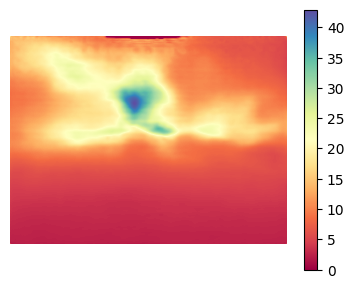

In [5]:
# viridis, gray
min_depth, max_depth = 1.97, 80
# min_depth, max_depth = 0, 80
# reg_factor, max_depth = dataset2params["mvsec"]["reg_factor"], dataset2params["mvsec"]["clip_distance"]
dep_path = "/home/sph/event/da2-prompt-tuning/results/test/epde_metric_sigloss_mvsec_night1_11/npy/00020.npy"
gt_path = "/data_nvme/sph/mvsec_processed/outdoor_night1/depths/00020.npy"

dep = np.load(dep_path)
print(dep.min(), dep.max())
gt = np.load(gt_path)

mask = (gt >= 40) & (gt <= 80)
print(mask.sum())

mask = (gt >= 1.97) & (gt <= 40)
print(mask.sum())
# dep = convert_nl2abs_depth(dep, reg_factor=reg_factor, clip_distance=max_depth)
# print(dep[np.isfinite(dep)].min(), dep[np.isfinite(dep)].max())
# mask = np.isfinite(gt)
# print(mask.sum())
# mask = np.isfinite(gt) & (gt <= 80)
# print(mask.sum())
# dep[dep > 80] = np.nan
# dep = 1 / dep
vis_depth_map(dep, save_fig=False, show_colorbar=True)
# vis_depth_map(gt, show_colorbar=False)

# vis_depth_map_filter(dep, gt, cmap_name='viridis')
# vis_depth_map_filter(dep, gt, show_colorbar=False)

# gt = np.clip(gt, min_depth, max_depth)
# vis_diff(dep, gt)
# vis_abs_diff(dep, gt)
# compare_depth_gt(dep, gt, min_depth, max_depth, show_colorbar=True)

In [ ]:
import os
dir = "/data_nvme/sph/mvsec_processed/outdoor_night3/depths"
depths = os.listdir(dir)
total_sum, under80 = 0, 0
min_depth, max_depth = 1.9704, 80

for d in depths:
    p = os.path.join(dir, d)
    map = np.load(p)
    
    mask = np.isfinite(map)
    total_sum = total_sum + mask.sum()
    mask = mask & (gt <= max_depth) & (gt >= min_depth)
    under80 = under80 + mask.sum()

print(len(depths), total_sum, under80, under80 * 1.0 / total_sum)
# 65921898 52455300 0.7957188975353835
# 66738442 53073060 0.7952397210591161
# 56254337 46382202 0.8245089085309103
# 210251379 173598434 0.8256708461350925
# 581360484 471406742 0.8108682219963199

# 4680 210251379 173595100 0.8256549889263747
# 10679 581360484 471258002 0.8106123738537413
# 1051 56254337 46202481 0.8213141148566021
# 1136 66738442 52878804 0.7923290148127821
# 1118 65921898 52264122 0.7928188293364976

In [ ]:
import torch
min_depth = torch.exp(-1 * torch.tensor(3.70378)) * torch.tensor(80)
print(min_depth)

In [ ]:
import os
txt_path = "/home/sph/event/da2-prompt-tuning/dataset/splits/mvsec/vis_feature.txt"
out_dir = "/home/sph/event/da2-prompt-tuning/vis_feature_maps/mvsec_fea_deps"
os.makedirs(out_dir, exist_ok=True)

with open(txt_path, 'r') as f:
    lines = f.readlines()
dep_paths = [l.split()[1] for l in lines]
for dep in dep_paths:
    out_path = os.path.join(out_dir, os.path.basename(dep).replace('npy', 'png'))
    dep_map = np.load(dep)
    dep_map = 1 / dep_map
    print(out_path)
    vis_depth_map(dep_map, save_fig=True, save_path=out_path)

#### Vis Scene (image, voxel, GT depth)

In [ ]:
# 1137, 2767, 2917
# i = "/data_nvme/sph/mvsec_processed/outdoor_day1/images/02917.png"
# v = "/data_nvme/sph/mvsec_processed/outdoor_day1/voxels/02917.npy"
# d = "/data_nvme/sph/mvsec_processed/outdoor_day1/depths/02917.npy"

# i = "/data/coding/upload-data/data/EventScape/Town05_test/Town05/sequence_0/rgb/data/05_000_0058_image.png"
# v = "/data/coding/upload-data/data/EventScape/Town05_test/Town05/sequence_0/events/voxels/05_000_0058_events.npy"
# d = "/data/coding/upload-data/data/EventScape/Town05_test/Town05/sequence_0/depth/data/05_000_0058_depth.npy"

i = "/data/coding/upload-data/data/EventScape/Town05_test/Town05/sequence_1/rgb/data/05_001_0070_image.png"
v = "/data/coding/upload-data/data/EventScape/Town05_test/Town05/sequence_1/events/voxels/05_001_0070_events.npy"
d = "/data/coding/upload-data/data/EventScape/Town05_test/Town05/sequence_1/depth/data/05_001_0070_depth.npy"
visualize_scene_from_paths(i, v, d, show_colorbar=True, set_title=True)

In [ ]:
i = "/data/coding/upload-data/data/EventScape/Town05_test/Town05/sequence_1/rgb/data/05_001_0070_image.png"
e = "/data/coding/upload-data/data/EventScape/Town05_test/Town05/sequence_1/events/data/05_001_0070_events.npz"
d = "/data/coding/upload-data/data/EventScape/Town05_test/Town05/sequence_1/depth/data/05_001_0070_depth.npy"

# i = "/data/coding/upload-data/data/EventScape/Town05_test/Town05/sequence_0/rgb/data/05_000_0058_image.png"
# e = "/data/coding/upload-data/data/EventScape/Town05_test/Town05/sequence_0/events/data/05_000_0058_events.npz"
# d = "/data/coding/upload-data/data/EventScape/Town05_test/Town05/sequence_0/depth/data/05_000_0058_depth.npy"
visualize_scene_from_paths_event(i, e, d, show_colorbar=True)

#### Vis event stream

In [ ]:
# mvsec:      width, height = 346, 260
# eventscape: width, height = 512, 256
p = "/data_nvme/sph/mvsec_processed/outdoor_night1/events/01744.npy"
events = np.load(p)

width, height = 346, 260
if p.endswith(".npz"):
    events = event_npz2npy(events)
    events[events[:, 3] == 0, 3] = -1

print(events.shape)
detect_sparsity(events, width=width, height=height)
# plot_3d_events(events)
plot_spatial_distribution(events, width=width, height=height, save_fig=True)

In [43]:
import os
txt_path = "/home/sph/event/da2-prompt-tuning/dataset/splits/mvsec/vis_feature.txt"
out_dir = "/home/sph/event/da2-prompt-tuning/vis_feature_maps/mvsec_fea_eves"
os.makedirs(out_dir, exist_ok=True)

with open(txt_path, 'r') as f:
    lines = f.readlines()
eve_paths = [l.split()[2].strip() for l in lines]
for eve in eve_paths:
    out_path = os.path.join(out_dir, os.path.basename(eve).replace('npy', 'png'))
    width, height = 346, 260
    eve = eve.replace("voxels", "events")
    print(eve)
    events = np.load(eve)
    print(out_path)
    plot_spatial_distribution(events, width=width, height=height, save_fig=True, save_path=out_path)

#### Vis Voxel Grid

In [ ]:
p = "/data/coding/upload-data/data/EventScape/Town05_test/Town05/sequence_1/events/voxels/05_001_0070_events.npy"
vox = np.load(p)
# vox = events_to_voxel_grid(events=events, num_bins=3, width=width, height=height)

vis_voxelgrid(vox)

In [ ]:
import h5py
import numpy as np

data_hdf5_path = "/data_nvme/sph/mvsec/outdoor_day1_data.hdf5"
gt_hdf5_path = "/data_nvme/sph/mvsec/outdoor_day1_gt.hdf5"

data = h5py.File(data_hdf5_path)
gt = h5py.File(gt_hdf5_path)

In [ ]:
depth_raw = np.array(gt['davis']['left']['depth_image_raw'])
depth_rect = np.array(gt['davis']['left']['depth_image_rect'])
print(depth_raw.shape, depth_rect.shape)

In [ ]:
compare_depth_gt(depth_rect[2917], depth_raw[2917], min_depth=0, max_depth=100, show_colorbar=True, cmap_name="viridis")

In [ ]:
diff = depth_raw[0] - depth_rect[0]
diff = np.clip(diff, -5, 5)
vis_depth_map(diff, show_colorbar=True, cmap_name="viridis")

In [42]:
import os
import shutil
txt_path = "/home/sph/event/da2-prompt-tuning/dataset/splits/mvsec/vis_feature.txt"
out_dir = "/home/sph/event/da2-prompt-tuning/vis_feature_maps/mvsec_fea_imgs"
os.makedirs(out_dir, exist_ok=True)

with open(txt_path, 'r') as f:
    lines = f.readlines()
img_paths = [l.split()[0].strip() for l in lines]
for img in img_paths:
    out_path = os.path.join(out_dir, os.path.basename(img))
    shutil.copy(img, out_path)